# Time Series Quantitative Analysis

## Section 1 - Import

In [3]:
# %pip install fredapi
# %pip install pandas
# %pip install matplotlib

In [4]:
# %pip install statsmodels

In [5]:
from fredapi import Fred
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
fred_api_key = "d1a4e88cb84c34808b5c07e2e62b61ec"

In [7]:
fred = Fred(api_key=fred_api_key)

In [8]:
# Fetch GDP data
gdp_data = fred.get_series('GDPC1')
gdp_data
# Convert to DataFrame
gdp_df = pd.DataFrame(gdp_data, columns=['gdp'])
gdp_df

,gdp
1947-01-01,2182.681
1947-04-01,2176.892
1947-07-01,2172.432
1947-10-01,2206.452
1948-01-01,2239.682
...,...
2024-10-01,23586.542
2025-01-01,23548.210
2025-04-01,23770.976
2025-07-01,24026.834


## Section 2 - Transformation

In [9]:
# Calculating the percentage change in GDP
gdp_df['pct_change'] = gdp_df['gdp'].pct_change() * 100
gdp_df

,gdp,pct_change
1947-01-01,2182.681,NaN
1947-04-01,2176.892,-0.265224
1947-07-01,2172.432,-0.204879
1947-10-01,2206.452,1.565987
1948-01-01,2239.682,1.506038
...,...,...
2024-10-01,23586.542,0.459875
2025-01-01,23548.210,-0.162516
2025-04-01,23770.976,0.946000
2025-07-01,24026.834,1.076346


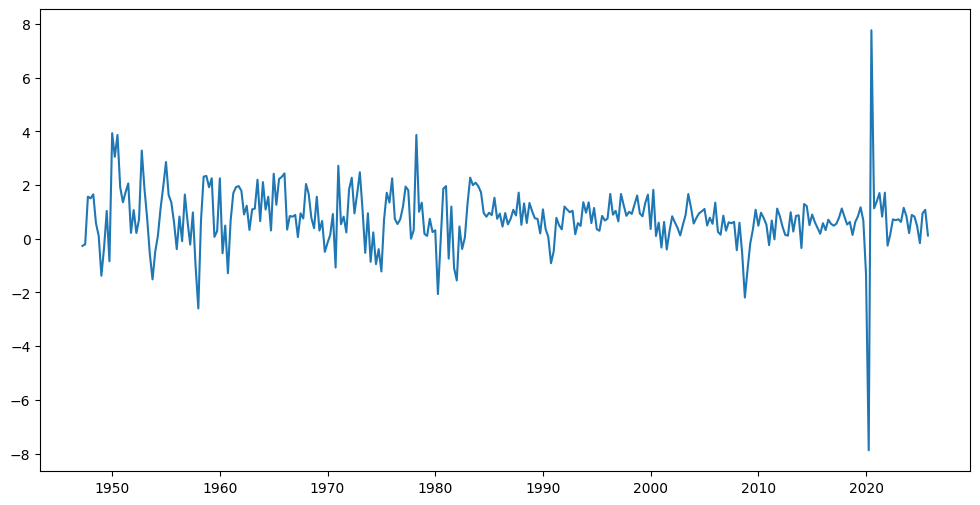

In [10]:
# Plotting the percentage change in GDP
plt.figure(figsize=(12, 6))
plt.plot(gdp_df.index, gdp_df['pct_change'], linestyle='-')
plt.show()

In [11]:
# Scatter plot of GDP percentage change and next quarter's percentage change
gdp_df['next_pct_change'] = gdp_df['pct_change'].shift(-1)
gdp_df

,gdp,pct_change,next_pct_change
1947-01-01,2182.681,NaN,-0.265224
1947-04-01,2176.892,-0.265224,-0.204879
1947-07-01,2172.432,-0.204879,1.565987
1947-10-01,2206.452,1.565987,1.506038
1948-01-01,2239.682,1.506038,1.652377
...,...,...,...
2024-10-01,23586.542,0.459875,-0.162516
2025-01-01,23548.210,-0.162516,0.946000
2025-04-01,23770.976,0.946000,1.076346
2025-07-01,24026.834,1.076346,0.120345


## Section 3 - Data Exploration

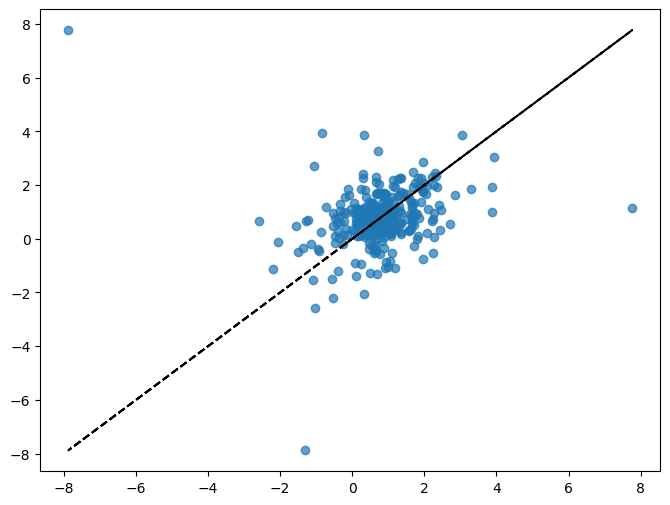

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(
    gdp_df['pct_change'],
    gdp_df['next_pct_change'],
    marker='o',
    alpha=0.7,
    )
# Least squares regression line
m, b = np.polyfit(gdp_df['pct_change'].dropna(), gdp_df['next_pct_change'].dropna(), 1)
plt.plot(gdp_df['pct_change'], m * gdp_df['pct_change'] + b, color='black', linestyle='--')
plt.show()

## Section 4 - Regressions

In [13]:
# Performing linear regression
m, b = np.polyfit(gdp_df['pct_change'].dropna(), gdp_df['next_pct_change'].dropna(), 1)

In [14]:
print(f"Slope: {round(m, 4)}, Intercept: {round(b, 4)}")

Slope: 1.0, Intercept: -0.0


In [15]:
# Candidate forecase errors
gdp_df['forecast'] = m * gdp_df['pct_change'] + b
gdp_df['forecast_error'] = gdp_df['next_pct_change'] - gdp_df['forecast']
gdp_df

,gdp,pct_change,next_pct_change,forecast,forecast_error
1947-01-01,2182.681,NaN,-0.265224,NaN,NaN
1947-04-01,2176.892,-0.265224,-0.204879,-0.265224,0.060345
1947-07-01,2172.432,-0.204879,1.565987,-0.204879,1.770866
1947-10-01,2206.452,1.565987,1.506038,1.565987,-0.059949
1948-01-01,2239.682,1.506038,1.652377,1.506038,0.146340
...,...,...,...,...,...
2024-10-01,23586.542,0.459875,-0.162516,0.459875,-0.622391
2025-01-01,23548.210,-0.162516,0.946000,-0.162516,1.108516
2025-04-01,23770.976,0.946000,1.076346,0.946000,0.130346
2025-07-01,24026.834,1.076346,0.120345,1.076346,-0.956002


In [16]:
# Number of lags
J = 12

## Section 5 - Autocorrelations

In [17]:
from statsmodels.graphics.tsaplots import plot_acf

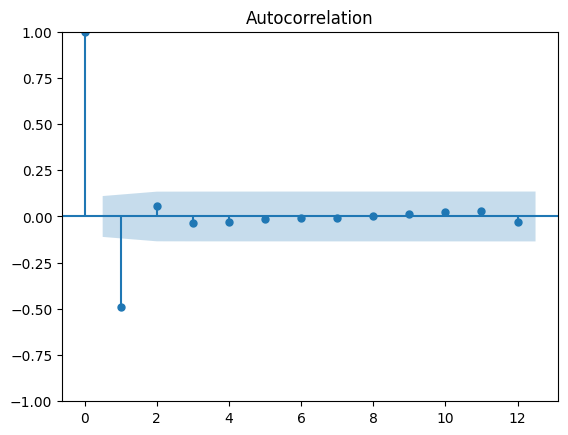

In [18]:
# Performing an autocorrelation analysis of the forecast errors
errors_acf = plot_acf(gdp_df['forecast_error'].dropna(), lags=J)
plt.show()


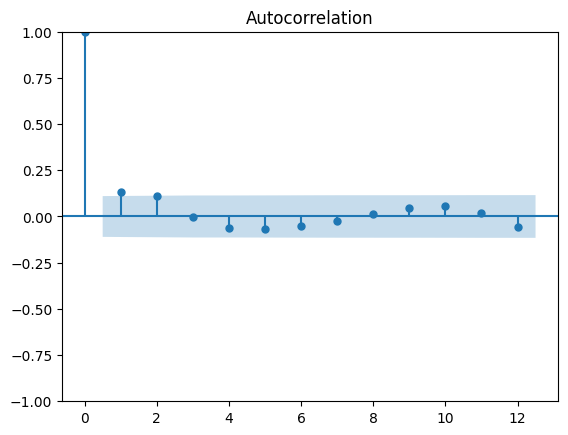

In [19]:
# This seems to be taking a long time. Not sure why.
rgdp_acf = plot_acf(gdp_df['pct_change'].dropna(), lags=J)
plt.show()